# **5.2 합성곱 신경망 맛보기**

* fashion_mnist 데이터셋을 이용해 합성곱 신경망을 직접 구현해본다
* 훈련 데이터셋 : 0~255 사이의 값을 갖는 28x28 크기의 넘파이 배열
* 레이블 데이터 : 0~9까지 정수 값


5-1. 라이브러리 호출

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

5-2.CPU 혹은 GPU 장치 확인

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

5-3. 데이터셋 내려받기

In [4]:
train_dataset  = torchvision.datasets.FashionMNIST("FashionMNIST/", download=True, transform=
                                                transforms.Compose([transforms.ToTensor()]))
test_dataset  = torchvision.datasets.FashionMNIST("FashionMNIST/", download=True, train=False, transform=
                                               transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 335kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.72MB/s]


5-4. fashion_mnist 데이터를 데이터로더에 전달

In [5]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=100)

5-5. 분류에 사용될 클래스 정의

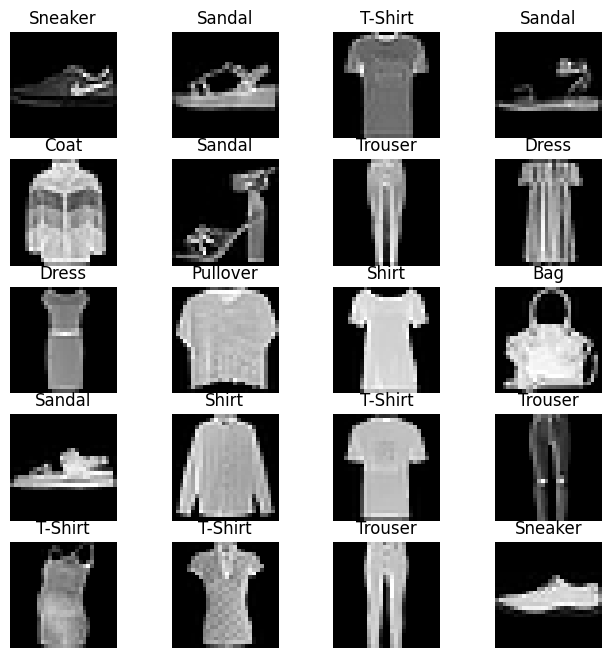

In [6]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt',
              7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'} #------- 열 개의 클래스

fig = plt.figure(figsize=(8,8)); #-------출력할 이미지 가로세로 길이 단위 inch
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset)); #-------(1)
    img = train_dataset[img_xy][0][0,:,:] #-------(2)
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show() #-------20개의 이미지 데이터를 시각적으로 현

5-6. 심층 신경망 모델 생성

In [7]:
class FashionDNN(nn.Module):
    def __init__(self): #-------(1)
        super(FashionDNN,self).__init__()
        self.fc1 = nn.Linear(in_features=784,out_features=256) #-------(2)
        self.drop = nn.Dropout2d(0.25) #-------(3)
        self.fc2 = nn.Linear(in_features=256,out_features=128)
        self.fc3 = nn.Linear(in_features=128,out_features=10)

    def forward(self,input_data):#-------(4)
        out = input_data.view(-1, 784) #-------(5)
        out = F.relu(self.fc1(out)) #-------(6)
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

5-7. 심층 신경망에서 필요한 파라미터 정의

In [8]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate); #-------(1)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


5-8.심층 신경망을 이용한 모델 학습

In [9]:
num_epochs = 5
count = 0
loss_list = [] #-------(1)
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader: #-------(2)
        images, labels = images.to(device), labels.to(device) #-------(3)

        train = Variable(images.view(100, 1, 28, 28)) #-------(4)
        labels = Variable(labels)

        outputs = model(train) #-------학습 데이터를 모델에 용
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50) :  #-------count를 50으로 나눴을 때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total #-------(5)
            loss_list.append(loss.data) #-------(1)'
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.5873286724090576, Accuracy: 83.12999725341797%
Iteration: 1000, Loss: 0.4998764097690582, Accuracy: 84.69000244140625%
Iteration: 1500, Loss: 0.38224101066589355, Accuracy: 84.30999755859375%
Iteration: 2000, Loss: 0.41831696033477783, Accuracy: 84.98999786376953%
Iteration: 2500, Loss: 0.2906903326511383, Accuracy: 86.23999786376953%
Iteration: 3000, Loss: 0.24850285053253174, Accuracy: 86.33000183105469%


5.9 합성곱 네트워크 생성

In [10]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential( #-------(1)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), #-------(2)
            nn.BatchNorm2d(32),#-------(3)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) #-------(4)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600) #-------(5)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10) #-------마지막 계층의 out_features는 클래스 개수를 의미한다

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) #-------(6)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

5-10. 합성곱 네트워크를 위한 파라미터 정의

In [11]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


5-11. 합성곱 네트워크를 위한 파라미터 정의

In [12]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4179854094982147, Accuracy: 87.58999633789062%
Iteration: 1000, Loss: 0.35362377762794495, Accuracy: 88.33000183105469%
Iteration: 1500, Loss: 0.31934964656829834, Accuracy: 88.70999908447266%
Iteration: 2000, Loss: 0.19044074416160583, Accuracy: 89.69999694824219%
Iteration: 2500, Loss: 0.12897445261478424, Accuracy: 89.77999877929688%
Iteration: 3000, Loss: 0.16886472702026367, Accuracy: 90.04000091552734%
